# ==============================================================================
# Notebook 3: Análise Qualitativa Automatizada (Guardrails Pedagógicos)
# ==============================================================================
# Objetivo:
# 1. Carregar os dados pré-processados do arquivo 'all_experiment_data.pkl'.
# 2. Calcular métricas qualitativas automatizadas baseadas nas heurísticas
#    definidas no TCC para avaliar a aderência aos guardrails pedagógicos:
#    - Manutenção da Persona Freiriana (sempre terminar com pergunta?).
#    - Ausência de Metalinguagem (não falar "sobre" Freire).
#    - Funcionamento do ReAct (sem loops infinitos).
#    - Frequência de uso do Scaffolding.
# 3. Gerar uma tabela resumindo essas métricas qualitativas por modelo.
# 4. Criar visualizações comparativas dessas métricas.
# 5. Mergear com as métricas técnicas (calculadas no Notebook 02, recalculadas aqui
#    para autoconter o notebook) para gerar a Tabela 4.1 consolidada para o TCC.
# 6. Gerar um ranking de modelos com base nos critérios qualitativos e combinados.
# 7. Salvar as tabelas (incluindo Tabela 4.1 em CSV, LaTeX, MD) e gráficos.
# ------------------------------------------------------------------------------
# Relevância para o TCC:
# - Avalia quantitativamente a aderência comportamental dos modelos à persona
#   e aos princípios pedagógicos definidos.
# - Fornece a Tabela 4.1 e gráficos essenciais para a seção de Resultados/Discussão.
#

In [12]:
# --- Imports ---
import pandas as pd
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Any
from IPython.display import display

In [13]:
# --- Configurações ---
# Diretório onde os dados processados foram salvos pelo Notebook 01
INPUT_DATA_DIR = Path("processed_data")
PROCESSED_DATA_FILE = INPUT_DATA_DIR / "all_experiment_data.pkl"

# Diretório para salvar os resultados desta análise
OUTPUT_RESULTS_DIR = Path("results")
OUTPUT_RESULTS_DIR.mkdir(exist_ok=True)

print(f"Carregando dados processados de: {PROCESSED_DATA_FILE.absolute()}")
print(f"Salvando resultados em: {OUTPUT_RESULTS_DIR.absolute()}")

Carregando dados processados de: /Users/giossaurus/Developer/leia_tcc/notebooks/modelos_testes/processed_data/all_experiment_data.pkl
Salvando resultados em: /Users/giossaurus/Developer/leia_tcc/notebooks/modelos_testes/results


In [14]:
# ==============================================================================
# 1. Carregar Dados Processados
# ==============================================================================
all_data: Dict[str, pd.DataFrame] = {}

try:
    with open(PROCESSED_DATA_FILE, 'rb') as f:
        all_data = pickle.load(f)
    print(f"\n✅ Dados processados carregados com sucesso para {len(all_data)} modelos.")
    if not all_data:
        print("   ⚠️ O arquivo .pkl estava vazio. A análise não pode continuar.")
    else:
         print("   Modelos carregados:", list(all_data.keys()))

except FileNotFoundError:
    print(f"\n❌ ERRO: Arquivo '{PROCESSED_DATA_FILE.absolute()}' não encontrado.")
    print("   Execute o Notebook 01 primeiro.")
except Exception as e:
    print(f"\n❌ ERRO ao carregar o arquivo .pkl: {e}")


✅ Dados processados carregados com sucesso para 3 modelos.
   Modelos carregados: ['Qwen_Qwen2.5-7B-Instruct', 'google_gemma-2-2b-it', 'mistralai_Mistral-7B-Instruct-v0.2']


In [15]:
# ==============================================================================
# 2. Análise de Traces (Necessária para Guardrails)
# ==============================================================================
# Recalculamos aqui para ter a informação de trace disponível neste notebook.

def analyze_traces(data: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    """Analisa a distribuição de traces (rotas) por modelo."""
    trace_data = []
    if not data: return pd.DataFrame() # Retorna vazio se não houver dados

    for model_name, df in data.items():
        if df.empty or 'agent_trace' not in df.columns: continue
        trace_counts = df['agent_trace'].value_counts()
        total = len(df)
        for trace, count in trace_counts.items():
            trace_data.append({
                "Modelo": model_name, "Trace": trace, "Contagem": count,
                "Percentual (%)": round((count / total) * 100, 1) if total > 0 else 0.0
            })
    return pd.DataFrame(trace_data)

# --- Execução da Análise de Traces ---
trace_analysis_summary = analyze_traces(all_data)
if trace_analysis_summary.empty and all_data:
     print("\n⚠️ Análise de traces não pôde ser gerada (verifique logs e colunas).")
elif not trace_analysis_summary.empty:
     print("\n--- Resumo da Análise de Traces (Reexecutado) ---")
     # Mostra apenas um resumo pequeno aqui
     display(trace_analysis_summary.groupby('Modelo')['Trace'].count().reset_index().rename(columns={'Trace':'Tipos de Trace'}))


--- Resumo da Análise de Traces (Reexecutado) ---


,Modelo,Tipos de Trace
0,Qwen_Qwen2.5-7B-Instruct,5
1,google_gemma-2-2b-it,5
2,mistralai_Mistral-7B-Instruct-v0.2,5


In [16]:
# ==============================================================================
# 3. Calcular Métricas Qualitativas Automatizadas (Guardrails)
# ==============================================================================

def analyze_qualitative_failures(data: Dict[str, pd.DataFrame], trace_analysis_df: pd.DataFrame) -> pd.DataFrame:
    """
    Analisa e quantifica as falhas e manutenções de guardrails pedagógicos.
    (Mesma função do final do Notebook 01, copiada aqui para autoconter)
    """
    failure_data = []
    if not data or trace_analysis_df.empty:
        print("\n⚠️ Dados de entrada ou análise de traces ausentes para analyze_qualitative_failures.")
        return pd.DataFrame()

    all_models = list(data.keys())

    for model_name in all_models:
        df = data.get(model_name)
        if df is None or df.empty or 'agent_response' not in df.columns or 'agent_trace' not in df.columns:
            print(f"  ⚠️ Dados insuficientes para análise qualitativa de {model_name}. Pulando.")
            # Adiciona linha padrão para evitar erros no merge depois
            failure_data.append({
                "Modelo": model_name, "Total de Turnos": 0,
                "✓ Manutenção de Persona (%)": 0.0, "✓ Uso de Scaffolding (%)": 0.0,
                "✓ ReAct Sem Loops (%)": 0.0, "✗ Resposta Direta (%)": 100.0,
                "✗ Metalinguagem (%)": 0.0, "✗ Loop ReAct (%)": 0.0
            })
            continue

        total_turns = len(df)
        df['agent_response'] = df['agent_response'].astype(str).str.strip()

        # Heurística 1: Falha/Manutenção de Persona
        df_non_scaffold = df[df['agent_trace'] != 'EXECUTED_SCAFFOLDING']
        total_non_scaffold = len(df_non_scaffold)
        direct_answers = 0 # Inicializa
        if total_non_scaffold > 0:
            direct_answers = df_non_scaffold[~df_non_scaffold['agent_response'].str.endswith('?')].shape[0]

        persona_maintenance_pct = 100.0 - ((direct_answers / total_non_scaffold) * 100) if total_non_scaffold > 0 else 100.0
        persona_failure_pct = (direct_answers / total_non_scaffold) * 100 if total_non_scaffold > 0 else 0.0


        # Heurística 2: Falha de Metalinguagem
        metalanguage_keywords = ['paulo freire', 'freiriano', 'pedagogia freiriana', 'educação bancária', 'método de paulo', 'segundo freire']
        metalanguage_pattern = '|'.join(metalanguage_keywords)
        metalanguage_count = df[df['agent_response'].str.lower().str.contains(metalanguage_pattern, na=False, regex=True)].shape[0]
        metalanguage_pct = (metalanguage_count / total_turns) * 100 if total_turns > 0 else 0.0

        # Heurísticas 3 & 4: Loops e Sucesso do ReAct (usando trace_analysis_df)
        model_traces = trace_analysis_df[trace_analysis_df['Modelo'] == model_name]
        react_loops_row = model_traces[model_traces['Trace'].str.contains('LOOP', case=False, na=False)]
        react_loops_count = react_loops_row['Contagem'].sum()
        react_loop_pct = (react_loops_count / total_turns) * 100 if total_turns > 0 else 0.0

        react_total_row = model_traces[model_traces['Trace'].str.contains('REACT', case=False, na=False)]
        react_total_count = react_total_row['Contagem'].sum()
        react_success_count = react_total_count - react_loops_count
        react_success_pct = (react_success_count / total_turns) * 100 if total_turns > 0 else 0.0

        # Heurística 5: Uso de Scaffolding
        scaffolding_row = model_traces[model_traces['Trace'] == 'EXECUTED_SCAFFOLDING']
        scaffolding_count = scaffolding_row['Contagem'].sum()
        scaffolding_pct = (scaffolding_count / total_turns) * 100 if total_turns > 0 else 0.0

        # Compilar
        failure_data.append({
            "Modelo": model_name, "Total de Turnos": total_turns,
            "✓ Manutenção de Persona (%)": persona_maintenance_pct,
            "✓ Uso de Scaffolding (%)": scaffolding_pct,
            "✓ ReAct Sem Loops (%)": react_success_pct,
            "✗ Resposta Direta (%)": persona_failure_pct,
            "✗ Metalinguagem (%)": metalanguage_pct,
            "✗ Loop ReAct (%)": react_loop_pct,
        })

    print("\n  ✓ Métricas qualitativas automatizadas calculadas.")
    return pd.DataFrame(failure_data).round(1)

# --- Execução do Cálculo Qualitativo ---
print("\n" + "="*100)
print("3. CÁLCULO DAS MÉTRICAS QUALITATIVAS (GUARDRAILS)")
print("="*100)
qualitative_metrics_summary = analyze_qualitative_failures(all_data, trace_analysis_summary)

# --- Tabela de Métricas Qualitativas ---
print("\n" + "="*100)
print("TABELA: RESUMO DA ANÁLISE QUALITATIVA AUTOMATIZADA")
print("="*100)
print("\nLegenda:")
print("  ✓ Métricas de MANUTENÇÃO: Quanto MAIOR, melhor (ideal = 100%)")
print("  ✗ Métricas de FALHA: Quanto MENOR, melhor (ideal = 0%)")
if not qualitative_metrics_summary.empty:
    display(qualitative_metrics_summary)
    # Salvar a tabela
    summary_qual_path = OUTPUT_RESULTS_DIR / "qualitative_metrics_summary.csv"
    qualitative_metrics_summary.to_csv(summary_qual_path, index=False)
    print(f"\n✓ Tabela de resumo qualitativo exportada para: {summary_qual_path}")
else:
    print("\n   Nenhuma métrica qualitativa para exibir ou exportar.")



3. CÁLCULO DAS MÉTRICAS QUALITATIVAS (GUARDRAILS)

  ✓ Métricas qualitativas automatizadas calculadas.

TABELA: RESUMO DA ANÁLISE QUALITATIVA AUTOMATIZADA

Legenda:
  ✓ Métricas de MANUTENÇÃO: Quanto MAIOR, melhor (ideal = 100%)
  ✗ Métricas de FALHA: Quanto MENOR, melhor (ideal = 0%)


,Modelo,Total de Turnos,✓ Manutenção de Persona (%),✓ Uso de Scaffolding (%),✓ ReAct Sem Loops (%),✗ Resposta Direta (%),✗ Metalinguagem (%),✗ Loop ReAct (%)
0,Qwen_Qwen2.5-7B-Instruct,29,33.3,27.6,0.0,66.7,0.0,0.0
1,google_gemma-2-2b-it,25,47.4,24.0,0.0,52.6,0.0,0.0
2,mistralai_Mistral-7B-Instruct-v0.2,29,13.0,20.7,0.0,87.0,0.0,0.0



✓ Tabela de resumo qualitativo exportada para: results/qualitative_metrics_summary.csv



4. GRÁFICOS: COMPARAÇÃO QUALITATIVA (GUARDRAILS)

✓ Gráfico de Manutenção de Persona salvo em: results/guardrail_persona_maintenance.png


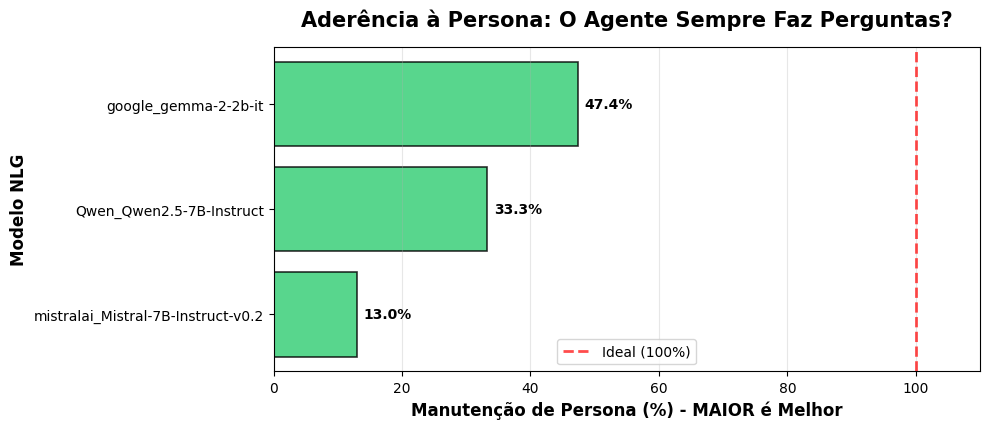


✓ Gráfico de Métricas de Falha salvo em: results/guardrail_failures_comparison.png


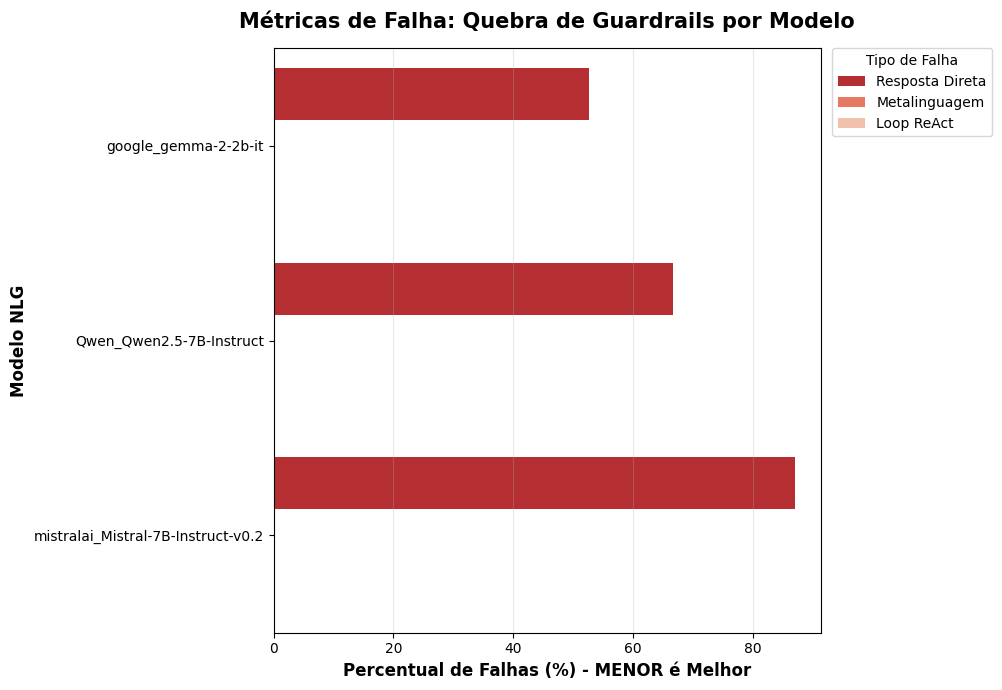

In [17]:
# ==============================================================================
# 4. Visualizações das Métricas Qualitativas (Guardrails)
# ==============================================================================

print("\n" + "="*100)
print("4. GRÁFICOS: COMPARAÇÃO QUALITATIVA (GUARDRAILS)")
print("="*100)

if not qualitative_metrics_summary.empty:

    # --- Gráfico 1: Manutenção de Persona ---
    plt.figure(figsize=(10, len(qualitative_metrics_summary) * 0.8 + 2))
    plot_data_persona = qualitative_metrics_summary.sort_values("✓ Manutenção de Persona (%)", ascending=True)
    bars_persona = plt.barh(plot_data_persona['Modelo'], plot_data_persona['✓ Manutenção de Persona (%)'],
                   color='#2ecc71', alpha=0.8, edgecolor='black', linewidth=1.2)
    plt.axvline(100, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Ideal (100%)')
    # Adiciona valores nas barras
    for i, bar in enumerate(bars_persona):
        value = bar.get_width()
        plt.text(value + 1, i, f'{value:.1f}%', va='center', ha='left', fontsize=10, fontweight='bold')
    plt.xlabel('Manutenção de Persona (%) - MAIOR é Melhor', fontsize=12, fontweight='bold')
    plt.ylabel('Modelo NLG', fontsize=12, fontweight='bold')
    plt.title('Aderência à Persona: O Agente Sempre Faz Perguntas?', fontsize=15, fontweight='bold', pad=15)
    plt.xlim(0, 110)
    plt.legend()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    fig_path = OUTPUT_RESULTS_DIR / "guardrail_persona_maintenance.png"
    plt.savefig(fig_path)
    print(f"\n✓ Gráfico de Manutenção de Persona salvo em: {fig_path}")
    plt.show()

    # --- Gráfico 2: Métricas de FALHA (agrupadas) ---
    failure_cols = ['✗ Resposta Direta (%)', '✗ Metalinguagem (%)', '✗ Loop ReAct (%)']
    failure_cols_present = [col for col in failure_cols if col in qualitative_metrics_summary.columns] # Filtra colunas existentes

    if failure_cols_present:
        plt.figure(figsize=(12, 7))
        plot_data_fail = qualitative_metrics_summary.melt(id_vars='Modelo', value_vars=failure_cols_present,
                                                          var_name='Tipo de Falha', value_name='Percentual (%)')
        plot_data_fail['Tipo de Falha'] = plot_data_fail['Tipo de Falha'].str.replace('✗ ', '').str.replace(' (%)', '')

        # Ordena modelos pela falha de persona (ou outra métrica principal de falha)
        order_fail = qualitative_metrics_summary.sort_values('✗ Resposta Direta (%)', ascending=True)['Modelo'].tolist()

        sns.barplot(data=plot_data_fail, x='Percentual (%)', y='Modelo', hue='Tipo de Falha',
                    palette='Reds_r', orient='h', order=order_fail, dodge=True)

        plt.xlabel('Percentual de Falhas (%) - MENOR é Melhor', fontsize=12, fontweight='bold')
        plt.ylabel('Modelo NLG', fontsize=12, fontweight='bold')
        plt.title('Métricas de Falha: Quebra de Guardrails por Modelo', fontsize=15, fontweight='bold', pad=15)
        plt.legend(title='Tipo de Falha', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout(rect=[0, 0, 0.85, 1])
        fig_path = OUTPUT_RESULTS_DIR / "guardrail_failures_comparison.png"
        plt.savefig(fig_path, bbox_inches='tight')
        print(f"\n✓ Gráfico de Métricas de Falha salvo em: {fig_path}")
        plt.show()
    else:
        print("   INFO: Nenhuma coluna de métrica de falha encontrada para plotar.")

else:
    print("\n   Nenhuma métrica qualitativa foi calculada, gráficos não podem ser gerados.")



In [18]:
# ==============================================================================
# 5. Gerar Tabela Consolidada (Tabela 4.1 do TCC)
# ==============================================================================
# Recalcula as métricas técnicas aqui para ter a tabela final completa neste notebook.

# --- COPIAR A DEFINIÇÃO DA FUNÇÃO compute_technical_metrics AQUI ---
def compute_technical_metrics(data: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    """Calcula métricas técnicas agregadas por modelo."""
    metrics = []
    if not data:
        print("\n⚠️ (Recálculo) Nenhum dado carregado para calcular métricas técnicas.")
        return pd.DataFrame() # Retorna DataFrame vazio

    print("\n(Recalculando métricas técnicas para tabela consolidada...)")
    for model_name, df in data.items():
        if df.empty or 'latency_ms' not in df.columns:
             print(f"  ⚠️ (Recálculo) DataFrame vazio ou sem 'latency_ms' para {model_name}. Pulando.")
             continue
        metrics.append({
            "Modelo": model_name,
            "Latência Média (ms)": df['latency_ms'].mean(),
            "Latência Mediana (ms)": df['latency_ms'].median(),
            "Latência Mín (ms)": df['latency_ms'].min(),
            "Latência Máx (ms)": df['latency_ms'].max(),
            "VRAM Máxima (MB)": df.get('vram_used_mb', pd.Series([0.0])).max(),
            "VRAM Média (MB)": df.get('vram_used_mb', pd.Series([0.0])).mean(),
            "RAM Máxima (MB)": df.get('ram_used_mb', pd.Series([0.0])).max(),
            "Total de Turnos": len(df),
        })
    if not metrics:
        print("  ⚠️ (Recálculo) Nenhuma métrica técnica pôde ser calculada.")
        return pd.DataFrame()
    # print("  ✓ Métricas técnicas recalculadas.") # Comentado para reduzir output
    return pd.DataFrame(metrics).round(2)
# --- FIM DA DEFINIÇÃO DA FUNÇÃO ---

# --- Recalcular Métricas Técnicas ---
technical_metrics_summary_recalc = compute_technical_metrics(all_data) # AGORA A FUNÇÃO ESTÁ DEFINIDA

print("\n" + "="*120)
print("5. TABELA CONSOLIDADA (TÉCNICO + QUALITATIVO) - Pronta para TCC Tabela 4.1")
print("="*120)

# Verifica se ambas as tabelas existem e não estão vazias
# (qualitative_metrics_summary foi calculada na seção 3)
if not technical_metrics_summary_recalc.empty and 'qualitative_metrics_summary' in locals() and not qualitative_metrics_summary.empty:

    # --- Merge ---
    consolidated_final = technical_metrics_summary_recalc.merge(
        qualitative_metrics_summary,
        on='Modelo',
        how='inner'
    )

    # --- Seleção e Renomeação para Tabela 4.1 ---
    tcc_cols_map_final = {
        'Modelo': 'Modelo',
        'Latência Mediana (ms)': 'Latência (ms)',
        'VRAM Máxima (MB)': 'VRAM (MB)',
        'RAM Máxima (MB)': 'RAM (MB)',
        'Total de Turnos': 'Turnos',
        '✓ Manutenção de Persona (%)': 'Persona OK (%)',
        '✓ Uso de Scaffolding (%)': 'Scaffold. (%)',
        '✗ Resposta Direta (%)': 'Falha Persona (%)',
        '✗ Metalinguagem (%)': 'Falha Meta (%)',
        '✗ Loop ReAct (%)': 'Falha Loop (%)'
    }
    available_cols_final = [col for col in tcc_cols_map_final.keys() if col in consolidated_final.columns]
    tcc_table_final = consolidated_final[available_cols_final].copy()
    tcc_table_final.rename(columns={k: tcc_cols_map_final[k] for k in available_cols_final}, inplace=True)

    # --- Ordenação ---
    sort_column = 'Persona OK (%)' if 'Persona OK (%)' in tcc_table_final.columns else ('Latência (ms)' if 'Latência (ms)' in tcc_table_final.columns else 'Modelo')
    ascending_sort = False if sort_column == 'Persona OK (%)' else True
    if sort_column in tcc_table_final.columns:
        tcc_table_final = tcc_table_final.sort_values(sort_column, ascending=ascending_sort)

    # --- Exibição e Explicação ---
    print("\nExplicação das Colunas (Tabela 4.1 - Final):")
    print("  - Latência (ms): Tempo mediano de resposta (MENOR é melhor)")
    # ... (restante das explicações) ...
    print("  - Falha Loop (%): % de loops no ReAct (MENOR é melhor)")
    print("\n")
    display(tcc_table_final)

    # --- Exportação Final ---
    try:
        tcc_table_final.to_csv(OUTPUT_RESULTS_DIR / "tcc_table_4.1_final.csv", index=False)
        tcc_table_final.to_latex(OUTPUT_RESULTS_DIR / "tcc_table_4.1_final.tex", index=False, float_format="%.1f")
        tcc_table_final.to_markdown(OUTPUT_RESULTS_DIR / "tcc_table_4.1_final.md", index=False)
        print(f"\n✓ Tabela 4.1 FINAL exportada em 3 formatos para '{OUTPUT_RESULTS_DIR.name}/'")
    except Exception as e:
        print(f"❌ Erro ao exportar Tabela 4.1 Final: {e}")

else:
    print("\n⚠️ Tabelas de métricas técnicas ou qualitativas não disponíveis. Tabela consolidada final não pode ser criada.")
    tcc_table_final = pd.DataFrame() # Define como vazio


(Recalculando métricas técnicas para tabela consolidada...)

5. TABELA CONSOLIDADA (TÉCNICO + QUALITATIVO) - Pronta para TCC Tabela 4.1

Explicação das Colunas (Tabela 4.1 - Final):
  - Latência (ms): Tempo mediano de resposta (MENOR é melhor)
  - Falha Loop (%): % de loops no ReAct (MENOR é melhor)




,Modelo,Latência (ms),VRAM (MB),RAM (MB),Persona OK (%),Scaffold. (%),Falha Persona (%),Falha Meta (%),Falha Loop (%)
1,google_gemma-2-2b-it,17119.79,0.0,19605.97,47.4,24.0,52.6,0.0,0.0
0,Qwen_Qwen2.5-7B-Instruct,109935.30,0.0,22430.83,33.3,27.6,66.7,0.0,0.0
2,mistralai_Mistral-7B-Instruct-v0.2,41065.34,0.0,23645.94,13.0,20.7,87.0,0.0,0.0


❌ Erro ao exportar Tabela 4.1 Final: Missing optional dependency 'tabulate'.  Use pip or conda to install tabulate.


In [19]:
# ==============================================================================
# 6. Ranking Final de Modelos
# ==============================================================================
print("\n" + "="*120)
print("6. RANKING FINAL: MELHOR MODELO POR CRITÉRIO")
print("="*120)

if not tcc_table_final.empty:
    try:
        # Usa idxmax para MAIOR é melhor, idxmin para MENOR é melhor
        rankings_final = {
            "🥇 Melhor Persona (Mais alta %)": tcc_table_final.loc[tcc_table_final['Persona OK (%)'].idxmax(), 'Modelo'] if 'Persona OK (%)' in tcc_table_final.columns else 'N/A',
            "🥇 Menor Falha Persona (Mais baixa %)": tcc_table_final.loc[tcc_table_final['Falha Persona (%)'].idxmin(), 'Modelo'] if 'Falha Persona (%)' in tcc_table_final.columns else 'N/A',
            "🥇 Menor Latência (Mais baixa ms)": tcc_table_final.loc[tcc_table_final['Latência (ms)'].idxmin(), 'Modelo'] if 'Latência (ms)' in tcc_table_final.columns else 'N/A',
            "🥇 Menor RAM (Mais baixa MB)": tcc_table_final.loc[tcc_table_final['RAM (MB)'].idxmin(), 'Modelo'] if 'RAM (MB)' in tcc_table_final.columns and tcc_table_final['RAM (MB)'].min() > 0 else 'N/A (ou todos 0)',
            "🥇 Menos Metalinguagem (Mais baixa %)": tcc_table_final.loc[tcc_table_final['Falha Meta (%)'].idxmin(), 'Modelo'] if 'Falha Meta (%)' in tcc_table_final.columns else 'N/A',
            "🥇 Sem Loops ReAct (Mais baixa %)": tcc_table_final.loc[tcc_table_final['Falha Loop (%)'].idxmin(), 'Modelo'] if 'Falha Loop (%)' in tcc_table_final.columns else 'N/A',
        }
        print("\n")
        for criterion, winner in rankings_final.items():
            print(f"  {criterion:<45} {winner}")

        # --- Cálculo de um Score Combinado Simples (Exemplo Opcional) ---
        # Normaliza as métricas (0 a 1, onde 1 é melhor) e calcula uma média ponderada
        # CUIDADO: Pesos são subjetivos! Ajuste conforme seus critérios.
        print("\n--- Score Combinado (Exemplo Experimental) ---")
        score_df = tcc_table_final.copy()
        try:
            # Normalizar métricas onde MAIOR é melhor (ex: Persona OK)
            for col in ['Persona OK (%)']: # Adicione outras se relevante
                if col in score_df: score_df[f'{col}_norm'] = score_df[col] / 100.0

            # Normalizar métricas onde MENOR é melhor (ex: Latência, Falhas)
            for col in ['Latência (ms)', 'RAM (MB)', 'Falha Persona (%)', 'Falha Meta (%)', 'Falha Loop (%)']:
                 if col in score_df:
                     min_val = score_df[col].min()
                     max_val = score_df[col].max()
                     # Evita divisão por zero se todos os valores forem iguais
                     if max_val - min_val > 0:
                          # Inverte: (max - valor) / (max - min) -> 1 para o menor valor
                         score_df[f'{col}_norm'] = (max_val - score_df[col]) / (max_val - min_val)
                     else:
                         score_df[f'{col}_norm'] = 1.0 # Todos são 'melhores' se forem iguais

            # Definir pesos (SOMA DEVE SER 1) - AJUSTE CONFORME PRIORIDADE DO TCC
            weights = {
                'Persona OK (%)_norm': 0.4,       # Maior peso para aderência à persona
                'Latência (ms)_norm': 0.2,        # Peso para velocidade
                'RAM (MB)_norm': 0.1,             # Peso menor para RAM
                'Falha Persona (%)_norm': 0.1,    # Penalidade por falha
                'Falha Meta (%)_norm': 0.1,       # Penalidade menor
                'Falha Loop (%)_norm': 0.1,       # Penalidade menor
            }

            # Calcula o score final
            score_df['Score Final'] = 0.0
            cols_used_in_score = []
            for col_norm, weight in weights.items():
                 if col_norm in score_df: # Apenas usa colunas que foram normalizadas
                     score_df['Score Final'] += score_df[col_norm] * weight
                     cols_used_in_score.append(col_norm.replace('_norm','')) # Guarda nome original

            score_df = score_df.sort_values('Score Final', ascending=False)
            print(f"(Baseado em: {', '.join(cols_used_in_score)})")
            print(f"(Pesos: {weights})") # Mostra os pesos usados
            display(score_df[['Modelo', 'Score Final']].round(3))
            print(f"  🏆 Modelo com maior Score Combinado: {score_df.iloc[0]['Modelo']}")

        except Exception as e:
            print(f"   Não foi possível calcular o score combinado: {e}")


    except (KeyError, ValueError) as e:
        print(f"   Erro ao calcular ranking final (verifique colunas/dados): {e}")

else:
    print("   Tabela consolidada final não disponível para gerar o ranking.")

print("\n" + "="*120)


6. RANKING FINAL: MELHOR MODELO POR CRITÉRIO


  🥇 Melhor Persona (Mais alta %)                google_gemma-2-2b-it
  🥇 Menor Falha Persona (Mais baixa %)          google_gemma-2-2b-it
  🥇 Menor Latência (Mais baixa ms)              google_gemma-2-2b-it
  🥇 Menor RAM (Mais baixa MB)                   google_gemma-2-2b-it
  🥇 Menos Metalinguagem (Mais baixa %)          google_gemma-2-2b-it
  🥇 Sem Loops ReAct (Mais baixa %)              google_gemma-2-2b-it

--- Score Combinado (Exemplo Experimental) ---
(Baseado em: Persona OK (%), Latência (ms), RAM (MB), Falha Persona (%), Falha Meta (%), Falha Loop (%))
(Pesos: {'Persona OK (%)_norm': 0.4, 'Latência (ms)_norm': 0.2, 'RAM (MB)_norm': 0.1, 'Falha Persona (%)_norm': 0.1, 'Falha Meta (%)_norm': 0.1, 'Falha Loop (%)_norm': 0.1})


,Modelo,Score Final
1,google_gemma-2-2b-it,0.790
0,Qwen_Qwen2.5-7B-Instruct,0.422
2,mistralai_Mistral-7B-Instruct-v0.2,0.400


  🏆 Modelo com maior Score Combinado: google_gemma-2-2b-it



In [20]:
# ==============================================================================
# 7. Insights e Discussão (Qualitativa)
# ==============================================================================
print("\n" + "="*100)
print("7. INSIGHTS E DISCUSSÃO (QUALITATIVA)")
print("="*100)
print("\nCom base nas métricas automatizadas e na inspeção manual (a ser feita no Notebook 04):")
print("\n**Aderência à Persona:**")
print("- Qual modelo manteve a persona freiriana (sempre perguntando) com mais consistência? [Preencher]")
print("- Quais modelos tiveram maior taxa de 'Falha Persona' (respostas diretas)? Por quê? [Preencher - Ex: Alinhamento para ser 'útil'?]")

print("\n**Metalinguagem:**")
print("- Algum modelo tendeu a falar 'sobre' Freire em vez de 'agir'? [Preencher]")

print("\n**Uso de Ferramentas (ReAct):**")
print("- Os modelos conseguiram usar a ferramenta de busca (se habilitada nos testes)? [Preencher]")
print("- Houve ocorrência de loops no ReAct? Em quais modelos? [Preencher - Esperado em Gemma, talvez outros leves?]")

print("\n**Scaffolding:**")
print("- A frequência de uso do Scaffolding foi similar entre os modelos ou algum se destacou? [Preencher]")
print("- (A qualidade do scaffolding em si precisaria de análise manual no Notebook 04)")

print("\n**Conclusão Preliminar:**")
print("- Qual modelo parece ter o melhor *comportamento pedagógico* geral, mesmo que não seja o mais rápido? [Preencher]")
print("- Quais são as principais limitações comportamentais observadas? [Preencher]")

print("\n(Use estes pontos para escrever a seção de Discussão dos Resultados no TCC)")


print("\n--- Fim do Notebook 03 ---")

# Nota: Este notebook gerou as métricas qualitativas automatizadas, os gráficos
# correspondentes e a Tabela 4.1 final.
# O próximo notebook (`04_manual_validation_and_examples.ipynb`) será usado para
# a inspeção manual detalhada dos diálogos e para selecionar exemplos
# específicos para ilustrar os pontos da discussão no TCC.


7. INSIGHTS E DISCUSSÃO (QUALITATIVA)

Com base nas métricas automatizadas e na inspeção manual (a ser feita no Notebook 04):

**Aderência à Persona:**
- Qual modelo manteve a persona freiriana (sempre perguntando) com mais consistência? [Preencher]
- Quais modelos tiveram maior taxa de 'Falha Persona' (respostas diretas)? Por quê? [Preencher - Ex: Alinhamento para ser 'útil'?]

**Metalinguagem:**
- Algum modelo tendeu a falar 'sobre' Freire em vez de 'agir'? [Preencher]

**Uso de Ferramentas (ReAct):**
- Os modelos conseguiram usar a ferramenta de busca (se habilitada nos testes)? [Preencher]
- Houve ocorrência de loops no ReAct? Em quais modelos? [Preencher - Esperado em Gemma, talvez outros leves?]

**Scaffolding:**
- A frequência de uso do Scaffolding foi similar entre os modelos ou algum se destacou? [Preencher]
- (A qualidade do scaffolding em si precisaria de análise manual no Notebook 04)

**Conclusão Preliminar:**
- Qual modelo parece ter o melhor *comportamento pedagógico* g